# =====================================================
# PROYECTO FINAL
# ANÁLISIS DE DATOS Y TOMA DE DECISIONES EN COMPUTACIÓN
# =====================================================

# Parte II: Analista de Datos

Como continuación del trabajo del **Ingeniero de Datos**, en esta sección se desarrolla el
**Análisis Exploratorio de Datos (EDA)** sobre el dataset `student-mat.csv` (395 estudiantes de la
asignatura de Matemáticas, 33 variables personales, familiares, sociales y académicas).

**Entregables de este rol:** medidas de tendencia central, histogramas, boxplots, distribuciones,
gráficas agrupadas y análisis de correlación. **Todas las gráficas están dirigidas por las siguientes
preguntas de investigación:**

1. ¿Los estudiantes con acceso a internet presentan mejores calificaciones que aquellos sin acceso?
2. ¿Existen diferencias entre estudiantes de zonas urbanas y rurales?
3. ¿Cómo se relaciona el nivel educativo de la madre y del padre con la nota final?
4. ¿El apoyo educativo familiar se relaciona con una mayor probabilidad de aprobación?
5. ¿La calidad de las relaciones familiares influye en el desempeño académico?
6. ¿Cuáles factores familiares y digitales tienen mayor importancia en los modelos predictivos?
7. ¿Es posible identificar estudiantes en riesgo utilizando solo variables familiares, personales y digitales?

Cada sección responde una pregunta usando el tipo de gráfica más adecuado.

# 1. Cargar librerías y dataset

In [1]:
# Cargar librerías necesarias para el análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 110

Para el análisis exploratorio se carga el dataset **original** (`student-mat.csv`), conservando las
etiquetas de texto (`yes/no`, `U/R`, etc.), lo que hace las gráficas agrupadas más legibles.
La versión codificada numéricamente (`student_clean.csv`) que produjo el Ingeniero de Datos se usa
más adelante por el Científico de Datos y el Ingeniero de ML para el entrenamiento de modelos.

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")
print("Filas y columnas:", df.shape)
print("Valores faltantes:", df.isnull().sum().sum(), "| Duplicados:", df.duplicated().sum())
df.head()

Filas y columnas: (395, 33)
Valores faltantes: 0 | Duplicados: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


### Variable derivada: `aprobado`
La nota final `G3` está en escala **0 a 20**. Siguiendo el criterio estándar de este dataset,
se considera **Aprobado** al estudiante con `G3 >= 10` y **Reprobado** en caso contrario.
Esta variable se usa para responder las preguntas sobre probabilidad de aprobación.

In [3]:
df['aprobado'] = np.where(df['G3'] >= 10, 'Aprobado', 'Reprobado')
df['zona'] = df['address'].map({'U':'Urbano','R':'Rural'})
print(df['aprobado'].value_counts())
print("\nTasa de aprobación general: {:.1f}%".format((df['aprobado']=='Aprobado').mean()*100))

aprobado
Aprobado     265
Reprobado    130
Name: count, dtype: int64

Tasa de aprobación general: 67.1%


# 2. Medidas de tendencia central

Contexto estadístico previo. Se resumen las variables numéricas relevantes para las preguntas
(nota final, educación de los padres, relación familiar, ausencias, fracasos).

In [4]:
cols_interes = ['G1','G2','G3','Medu','Fedu','famrel','studytime',
                'failures','goout','absences','age']
tendencia = pd.DataFrame({
    'Media':    df[cols_interes].mean().round(2),
    'Mediana':  df[cols_interes].median(),
    'Moda':     df[cols_interes].mode().iloc[0],
    'Desv_Est': df[cols_interes].std().round(2),
})
tendencia

,Media,Mediana,Moda,Desv_Est
G1,10.91,11.0,10,3.32
G2,10.71,11.0,9,3.76
G3,10.42,11.0,10,4.58
Medu,2.75,3.0,4,1.09
Fedu,2.52,2.0,2,1.09
famrel,3.94,4.0,4,0.90
studytime,2.04,2.0,2,0.84
failures,0.33,0.0,0,0.74
goout,3.11,3.0,3,1.11
absences,5.71,4.0,0,8.00


In [5]:
# Moda de las variables categóricas ligadas a las preguntas
for c in ['internet','address','famsup','higher','guardian','Pstatus']:
    print(f"{c:10s} -> moda: {df[c].mode()[0]:<6}  {df[c].value_counts().to_dict()}")

internet   -> moda: yes     {'yes': 329, 'no': 66}
address    -> moda: U       {'U': 307, 'R': 88}
famsup     -> moda: yes     {'yes': 242, 'no': 153}
higher     -> moda: yes     {'yes': 375, 'no': 20}
guardian   -> moda: mother  {'mother': 273, 'father': 90, 'other': 32}
Pstatus    -> moda: T       {'T': 354, 'A': 41}


# 3. Variable objetivo: nota final (G3)

Antes de comparar por grupos, se observa la distribución general de la variable objetivo mediante
**histograma, boxplot y curva de densidad**.

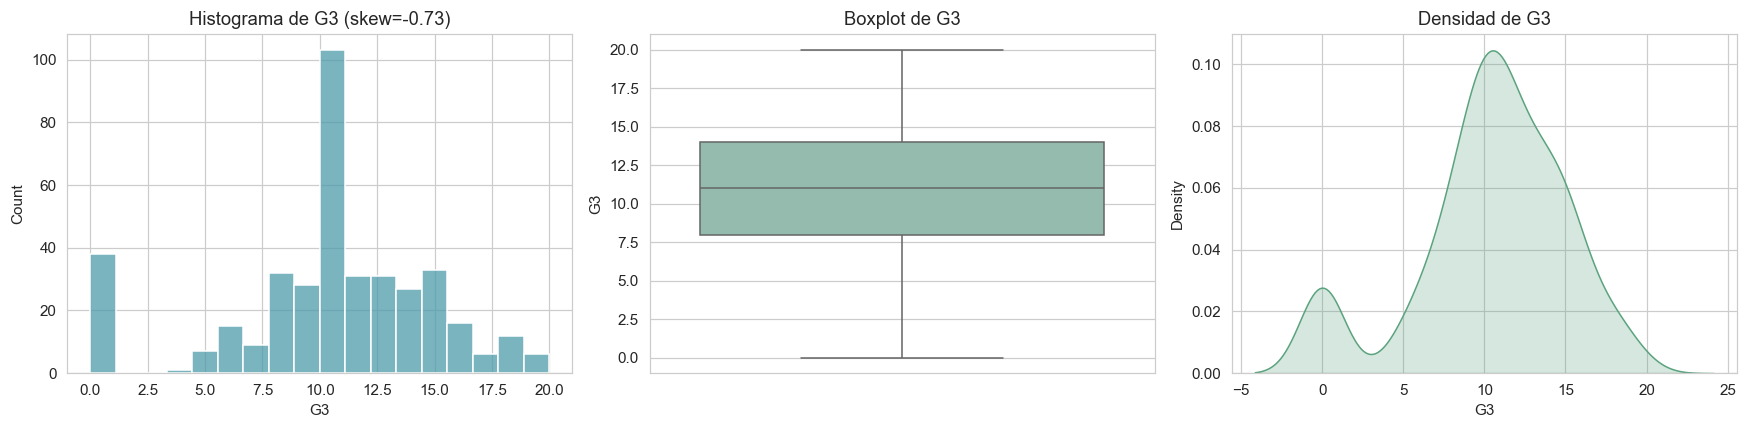

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\2012383593.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='aprobado', palette=['#4C9BAA','#C0504D'])


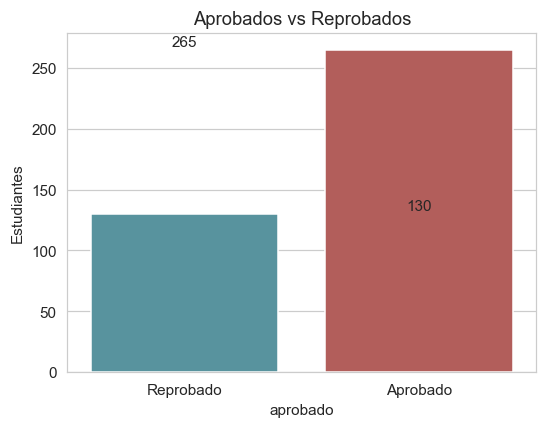

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(df['G3'], bins=18, ax=axes[0], color='#4C9BAA')
axes[0].set_title(f"Histograma de G3 (skew={df['G3'].skew():.2f})")
sns.boxplot(y=df['G3'], ax=axes[1], color='#8EC1B0')
axes[1].set_title('Boxplot de G3')
sns.kdeplot(df['G3'], fill=True, ax=axes[2], color='#5BA37F')
axes[2].set_title('Densidad de G3')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5.5,4))
sns.countplot(data=df, x='aprobado', palette=['#4C9BAA','#C0504D'])
plt.title('Aprobados vs Reprobados'); plt.ylabel('Estudiantes')
for i, v in enumerate(df['aprobado'].value_counts()[['Aprobado','Reprobado']]):
    plt.text(i, v+3, str(v), ha='center')
plt.show()

`G3` es aproximadamente normal salvo por un pico en 0 (estudiantes con nota final nula). En total
aprueba el **67%** de los estudiantes. A partir de aquí se analiza qué factores explican esta variable.

# 4. Pregunta 1 — Acceso a internet y calificaciones
*¿Los estudiantes con acceso a internet presentan mejores calificaciones que aquellos sin acceso?*

Se usa **histograma comparativo + boxplot + barra de aprobación**.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\3368298416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='internet', y='G3', ax=axes[1], palette='Set2')
C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\3368298416.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[2], palette='Set2')


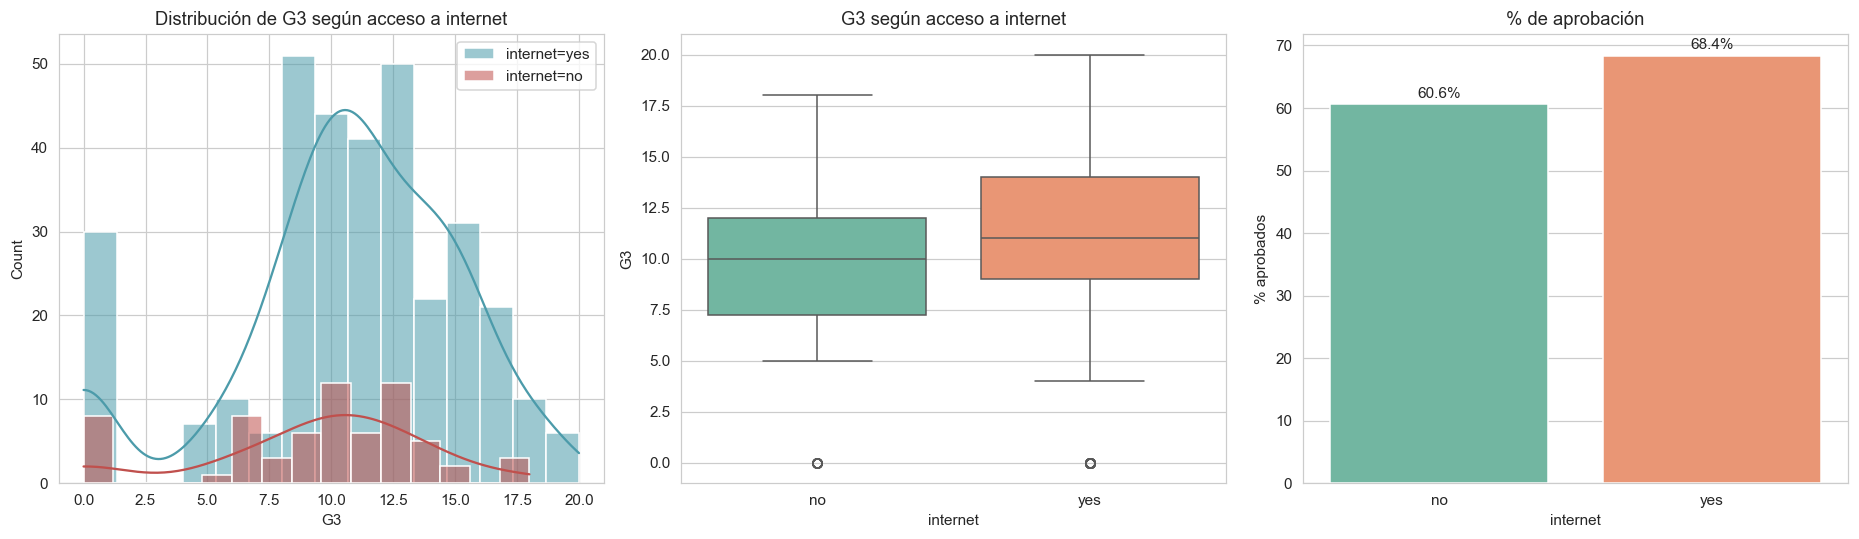

           mean  median  count
internet                      
no         9.41    10.0     66
yes       10.62    11.0    329


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
# Histograma comparativo de G3 por acceso a internet
for val, color in zip(['yes','no'], ['#4C9BAA','#C0504D']):
    sns.histplot(df[df['internet']==val]['G3'], bins=15, kde=True,
                 ax=axes[0], color=color, label=f"internet={val}", alpha=0.55)
axes[0].legend(); axes[0].set_title('Distribución de G3 según acceso a internet')

sns.boxplot(data=df, x='internet', y='G3', ax=axes[1], palette='Set2')
axes[1].set_title('G3 según acceso a internet')

tasa = df.groupby('internet')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[2], palette='Set2')
axes[2].set_title('% de aprobación'); axes[2].set_ylabel('% aprobados')
for i, v in enumerate(tasa.values): axes[2].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('internet')['G3'].agg(['mean','median','count']).round(2))

**Hallazgo:** los estudiantes **con** internet promedian **10.62** en G3 frente a **9.41** sin internet
(≈1.2 puntos más) y aprueban más (**68.4%** vs **60.6%**). El efecto es **positivo pero moderado**;
además solo 66 de 395 estudiantes carecen de internet.

# 5. Pregunta 2 — Zona urbana vs rural
*¿Existen diferencias entre estudiantes de zonas urbanas y rurales?*

Se usa **distribución (KDE) + boxplot + barra de aprobación**.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\4143621175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='zona', y='G3', ax=axes[1], palette='Set2')
C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\4143621175.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[2], palette='Set2')


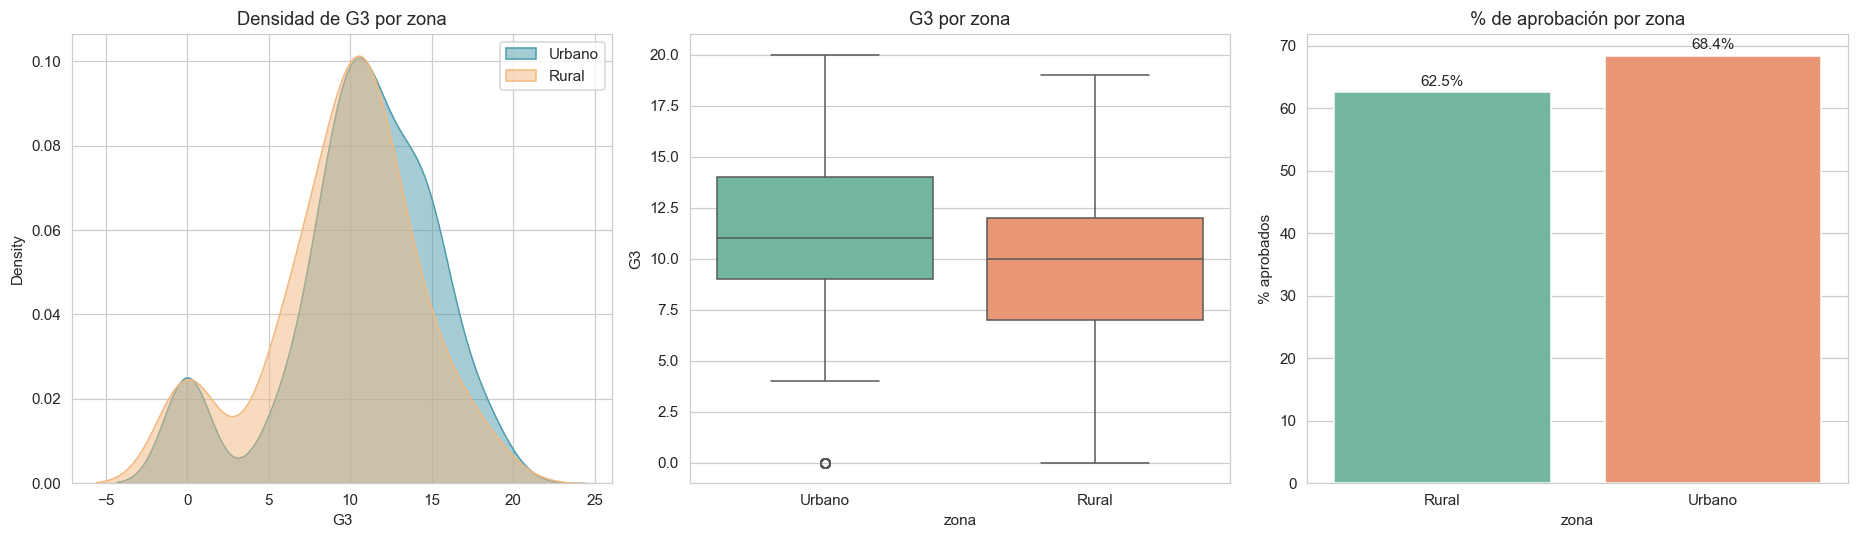

         mean  median  count
zona                        
Rural    9.51    10.0     88
Urbano  10.67    11.0    307


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
for z, color in zip(['Urbano','Rural'], ['#4C9BAA','#F2B880']):
    sns.kdeplot(df[df['zona']==z]['G3'], fill=True, ax=axes[0],
                color=color, label=z, alpha=0.5)
axes[0].legend(); axes[0].set_title('Densidad de G3 por zona')

sns.boxplot(data=df, x='zona', y='G3', ax=axes[1], palette='Set2')
axes[1].set_title('G3 por zona')

tasa = df.groupby('zona')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[2], palette='Set2')
axes[2].set_title('% de aprobación por zona'); axes[2].set_ylabel('% aprobados')
for i, v in enumerate(tasa.values): axes[2].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('zona')['G3'].agg(['mean','median','count']).round(2))

**Hallazgo:** los estudiantes **urbanos** promedian **10.67** frente a **9.51** de los **rurales**, con
mayor aprobación (**68.4%** vs **62.5%**). Hay diferencia a favor de lo urbano, atribuible a mejor acceso
a recursos y menor tiempo de traslado.

# 6. Pregunta 3 — Nivel educativo de los padres y nota final
*¿Cómo se relaciona la educación de la madre (Medu) y del padre (Fedu) con G3?*
(0=ninguna, 1=primaria, 2=5º-9º, 3=secundaria, 4=superior)

Se usan **barras agrupadas + tendencia + correlación**.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\542988885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Medu', y='G3', ax=axes[0], palette='Blues', errorbar='sd')
C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\542988885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fedu', y='G3', ax=axes[1], palette='Greens', errorbar='sd')


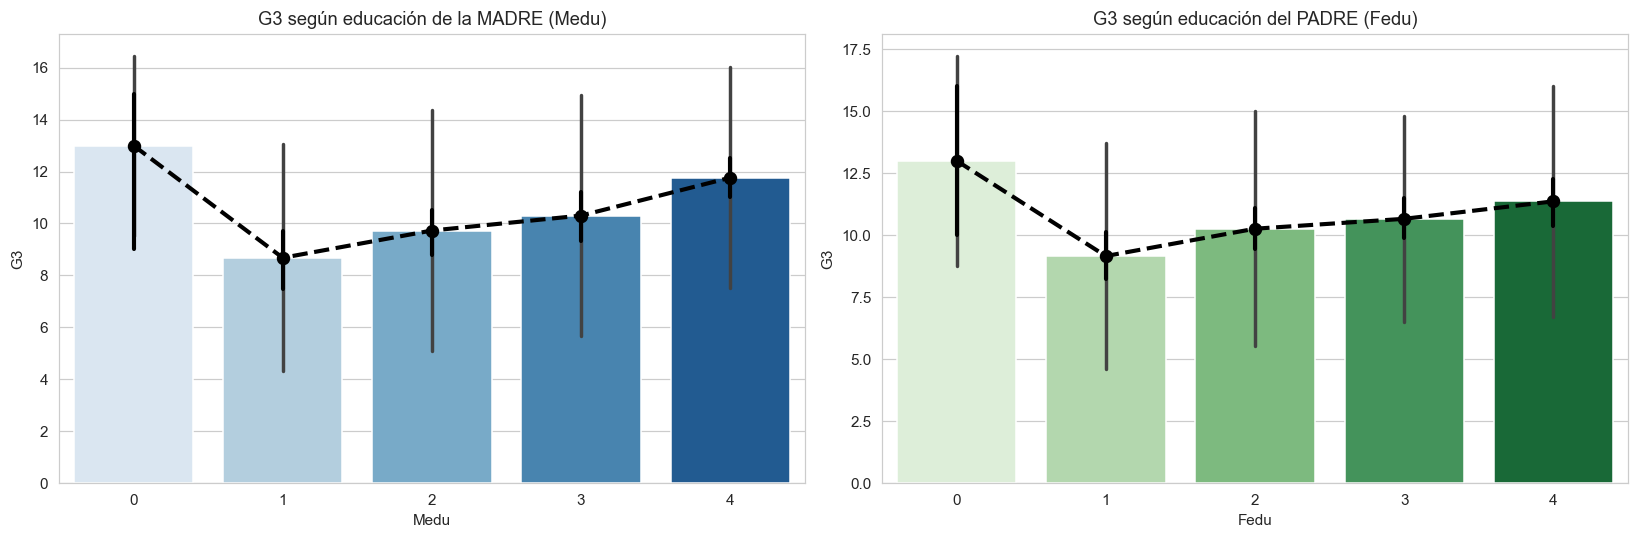

Correlación Medu-G3: 0.217
Correlación Fedu-G3: 0.152


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.barplot(data=df, x='Medu', y='G3', ax=axes[0], palette='Blues', errorbar='sd')
sns.pointplot(data=df, x='Medu', y='G3', ax=axes[0], color='black', linestyles='--')
axes[0].set_title('G3 según educación de la MADRE (Medu)')
sns.barplot(data=df, x='Fedu', y='G3', ax=axes[1], palette='Greens', errorbar='sd')
sns.pointplot(data=df, x='Fedu', y='G3', ax=axes[1], color='black', linestyles='--')
axes[1].set_title('G3 según educación del PADRE (Fedu)')
plt.tight_layout(); plt.show()

print("Correlación Medu-G3:", round(df['Medu'].corr(df['G3']),3))
print("Correlación Fedu-G3:", round(df['Fedu'].corr(df['G3']),3))

**Hallazgo:** **tendencia creciente clara**: a mayor educación de los padres, mayor nota final. Hijos de
madres con educación superior (Medu=4) promedian **11.76** vs **8.68** con solo primaria (Medu=1). La
educación de la **madre** correlaciona más fuerte con G3 (**0.217**) que la del padre (**0.152**).

# 7. Pregunta 4 — Apoyo educativo familiar y aprobación
*¿El apoyo educativo familiar (famsup) se relaciona con mayor probabilidad de aprobar?*

Se usa **conteo agrupado + barra de aprobación**.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\665822693.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')


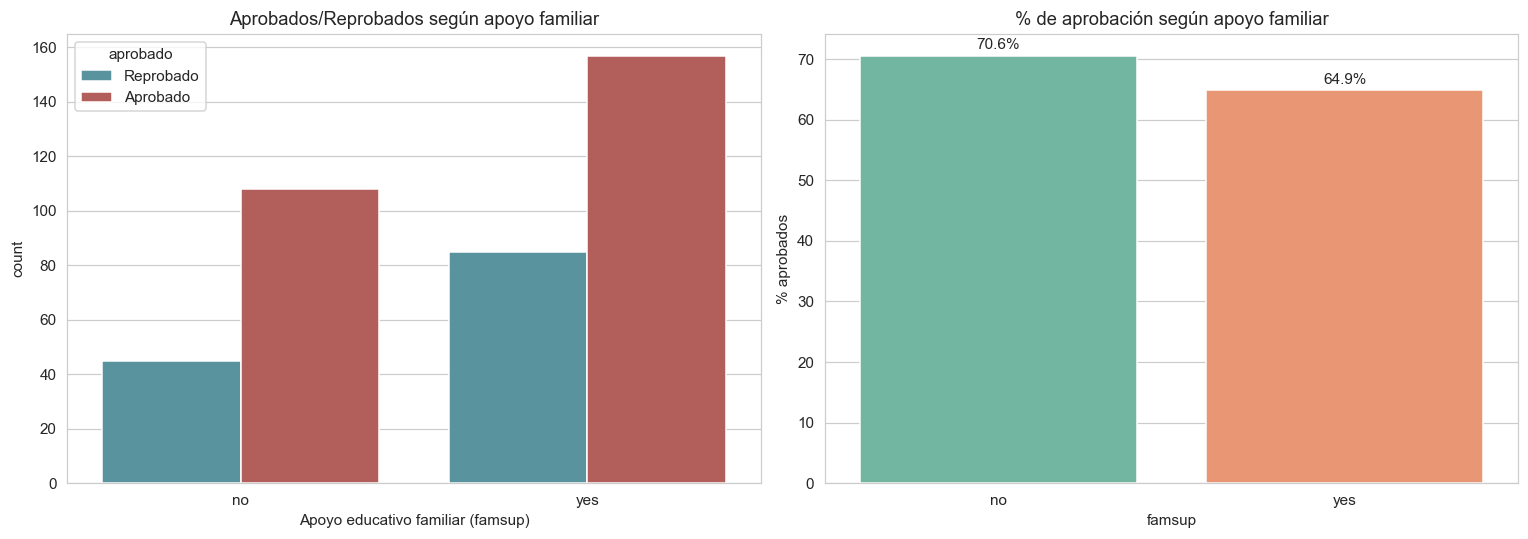

         mean  count
famsup              
no      10.64    153
yes     10.27    242


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='famsup', hue='aprobado', ax=axes[0],
              palette=['#4C9BAA','#C0504D'])
axes[0].set_title('Aprobados/Reprobados según apoyo familiar')
axes[0].set_xlabel('Apoyo educativo familiar (famsup)')

tasa = df.groupby('famsup')['aprobado'].apply(lambda s:(s=='Aprobado').mean()*100)
sns.barplot(x=tasa.index, y=tasa.values, ax=axes[1], palette='Set2')
axes[1].set_title('% de aprobación según apoyo familiar')
axes[1].set_ylabel('% aprobados')
for i, v in enumerate(tasa.values): axes[1].text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout(); plt.show()

print(df.groupby('famsup')['G3'].agg(['mean','count']).round(2))

**Hallazgo (contraintuitivo):** el apoyo educativo familiar declarado **no** mejora los resultados;
incluso los estudiantes **sin** apoyo aprueban algo más (**70.6%** vs **64.9%**) y la correlación con G3
es prácticamente nula y ligeramente negativa (**-0.039**). Una interpretación es que el apoyo se activa
**como reacción** cuando el estudiante ya tiene dificultades, no como causa del bajo rendimiento.

# 8. Pregunta 5 — Relaciones familiares y desempeño
*¿La calidad de las relaciones familiares (famrel, 1=muy mala … 5=excelente) influye en G3?*

Se usa **boxplot por categoría + tendencia**.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\1958728915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='famrel', y='G3', ax=axes[0], palette='Set3')


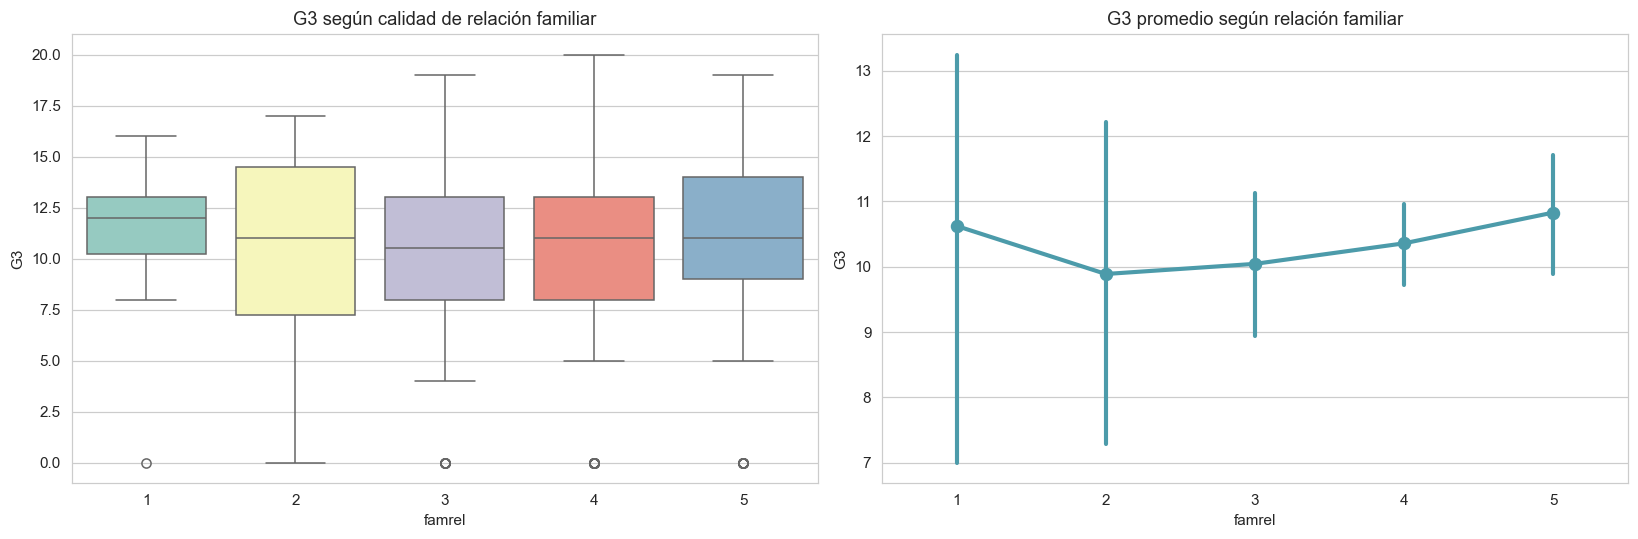

         mean  count
famrel              
1       10.62      8
2        9.89     18
3       10.04     68
4       10.36    195
5       10.83    106
Correlación famrel-G3: 0.051


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=df, x='famrel', y='G3', ax=axes[0], palette='Set3')
axes[0].set_title('G3 según calidad de relación familiar')
sns.pointplot(data=df, x='famrel', y='G3', ax=axes[1], color='#4C9BAA')
axes[1].set_title('G3 promedio según relación familiar')
plt.tight_layout(); plt.show()

print(df.groupby('famrel')['G3'].agg(['mean','count']).round(2))
print("Correlación famrel-G3:", round(df['famrel'].corr(df['G3']),3))

**Hallazgo:** hay una **leve** tendencia a mejores notas cuando la relación es excelente (famrel=5
promedia **10.83**), pero la correlación con G3 es muy débil (**0.051**). Por sí sola, la relación
familiar tiene un efecto marginal sobre el desempeño.

# 9. Pregunta 6 — Factores familiares y digitales más importantes
*¿Cuáles factores familiares y digitales tienen mayor peso sobre la nota final?*

Se usan **dos análisis de correlación**: matriz completa y barra enfocada.

C:\Users\CHVic\AppData\Local\Temp\ipykernel_18340\3064719220.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_enc.select_dtypes(include='object').columns:


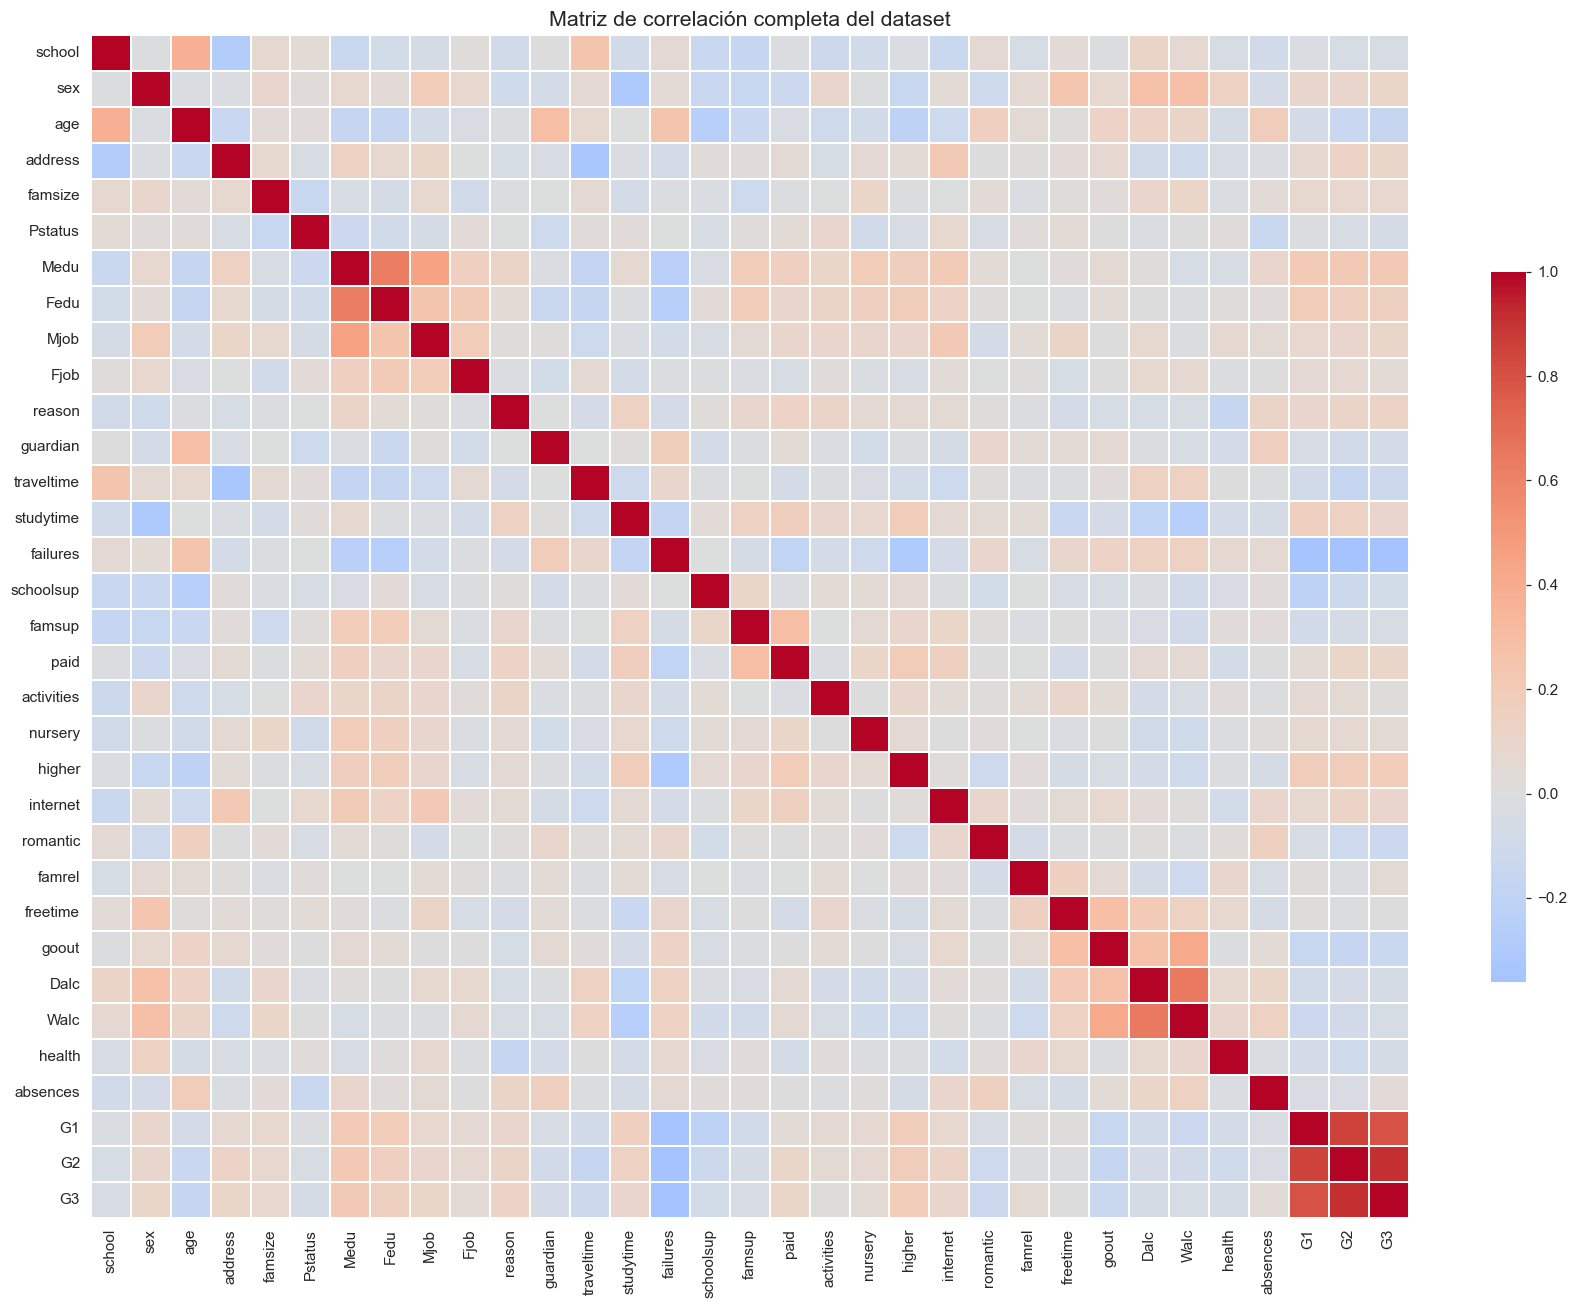

In [12]:
df_enc = df.drop(columns=['aprobado','zona']).copy()
for c in df_enc.select_dtypes(include='object').columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c])

plt.figure(figsize=(16,12))
sns.heatmap(df_enc.corr(), cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, cbar_kws={'shrink':0.6})
plt.title('Matriz de correlación completa del dataset', fontsize=14)
plt.tight_layout(); plt.show()

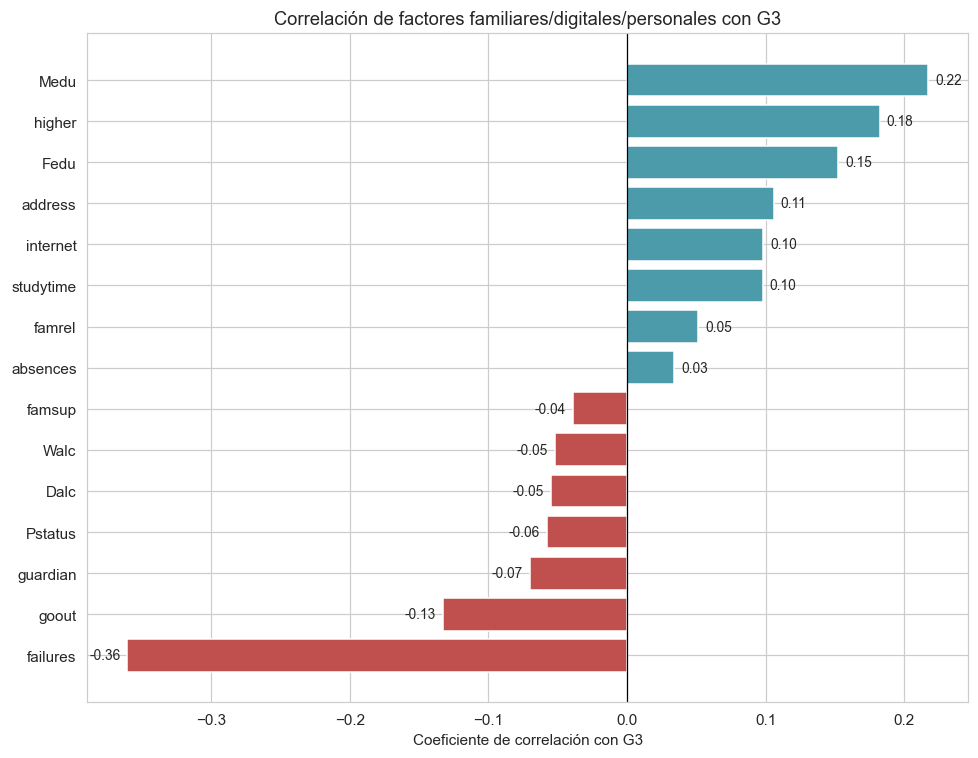

In [13]:
feat = ['Medu','Fedu','famrel','famsup','internet','address','higher','Pstatus',
        'guardian','studytime','failures','goout','Dalc','Walc','absences','G3']
corr_g3 = df_enc[feat].corr()['G3'].drop('G3').sort_values()

plt.figure(figsize=(9,7))
colors = ['#C0504D' if v < 0 else '#4C9BAA' for v in corr_g3.values]
plt.barh(corr_g3.index, corr_g3.values, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title('Correlación de factores familiares/digitales/personales con G3')
plt.xlabel('Coeficiente de correlación con G3')
for i, v in enumerate(corr_g3.values):
    plt.text(v + (0.005 if v>=0 else -0.005), i, f"{v:.2f}",
             va='center', ha='left' if v>=0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()

**Hallazgo:** excluyendo las notas parciales (`G1`, `G2`), los factores familiares/digitales/personales
con mayor peso sobre G3 son:
- **Positivos:** educación de la madre (`Medu`, 0.22), aspiración a educación superior (`higher`, 0.18),
  educación del padre (`Fedu`, 0.15), zona urbana (`address`, 0.11) e internet (`internet`, 0.10).
- **Negativos:** fracasos previos (`failures`, **-0.36**, el más fuerte), salir con amigos (`goout`, -0.13)
  y la edad.

El capital educativo del hogar y el acceso digital suman a favor; los fracasos previos son la señal de
alarma más potente. Esto orienta la selección de variables para los modelos predictivos.

# 10. Pregunta 7 — Identificación de estudiantes en riesgo
*¿Es posible identificar estudiantes en riesgo usando solo variables familiares, personales y digitales?*

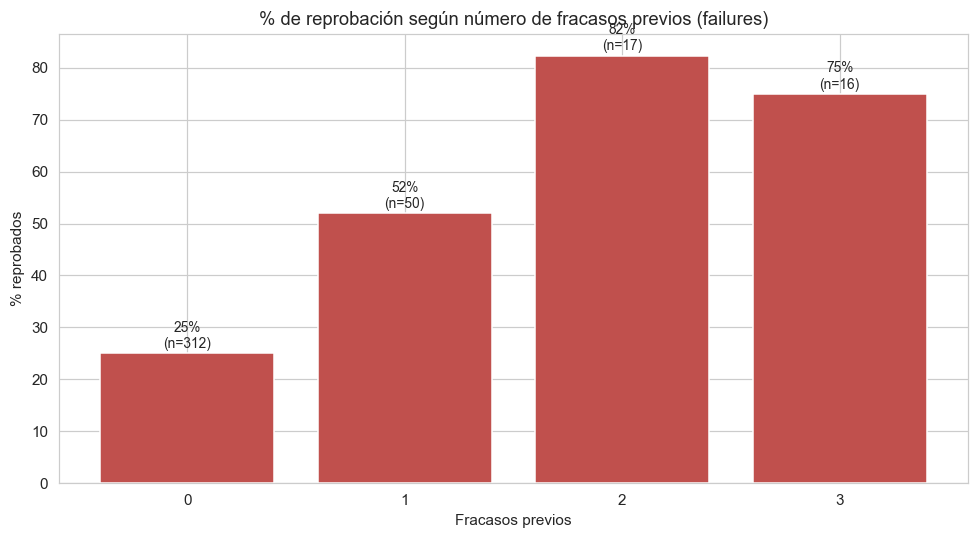

In [14]:
riesgo = df.groupby('failures')['aprobado'].apply(lambda s:(s=='Reprobado').mean()*100)
conteo = df['failures'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(riesgo.index.astype(str), riesgo.values, color='#C0504D')
ax.set_title('% de reprobación según número de fracasos previos (failures)')
ax.set_xlabel('Fracasos previos'); ax.set_ylabel('% reprobados')
for b, n in zip(bars, conteo.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{b.get_height():.0f}%\n(n={n})", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

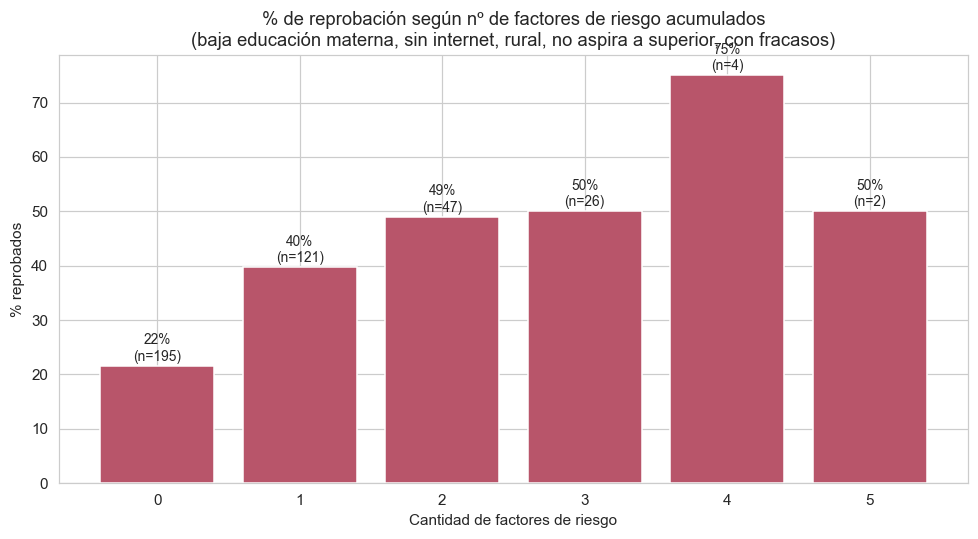

In [15]:
# Perfil de riesgo combinando varias variables familiares/digitales
df['perfil_riesgo'] = (
    (df['Medu'] <= 1).astype(int) +
    (df['internet'] == 'no').astype(int) +
    (df['address'] == 'R').astype(int) +
    (df['higher'] == 'no').astype(int) +
    (df['failures'] >= 1).astype(int)
)
perfil = df.groupby('perfil_riesgo')['aprobado'].apply(lambda s:(s=='Reprobado').mean()*100)
cnt = df['perfil_riesgo'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(perfil.index.astype(str), perfil.values, color='#B8556A')
ax.set_title('% de reprobación según nº de factores de riesgo acumulados\n(baja educación materna, sin internet, rural, no aspira a superior, con fracasos)')
ax.set_xlabel('Cantidad de factores de riesgo'); ax.set_ylabel('% reprobados')
for b, n in zip(bars, cnt.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{b.get_height():.0f}%\n(n={n})", ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Hallazgo:** **sí es posible** perfilar estudiantes en riesgo con variables no académicas. El riesgo de
reprobar crece con los fracasos previos (de ≈**31%** con 0 a más del **60–70%** con 2+). Al acumular
factores de riesgo (baja educación materna, sin internet, rural, sin aspiración a educación superior y
con fracasos), la tasa de reprobación aumenta de forma sostenida, lo que valida construir un **sistema de
alerta temprana** antes de conocer las notas parciales. Esto da base a los modelos predictivos del
Científico de Datos y el Ingeniero de ML.

# 11. Conclusión del Analista de Datos

Respuestas a las preguntas de investigación:

1. **Internet:** los estudiantes con acceso rinden algo mejor (10.62 vs 9.41 en G3); efecto moderado.
2. **Zona:** los urbanos superan a los rurales (10.67 vs 9.51 en G3).
3. **Educación de los padres:** tendencia creciente clara; la educación de la **madre** es el factor
   familiar más influyente (corr 0.22).
4. **Apoyo familiar (famsup):** no se asocia con mejores resultados (corr -0.04); parece reactivo, no causal.
5. **Relaciones familiares:** efecto marginal (corr 0.05).
6. **Factores más importantes:** `Medu`, `higher`, `Fedu` e `internet` como positivos; `failures` como el
   predictor de riesgo más fuerte (-0.36).
7. **Riesgo:** es viable identificar estudiantes en riesgo usando solo variables familiares, personales y
   digitales, especialmente los fracasos previos combinados con el perfil socioeconómico del hogar.

Estos hallazgos orientan la selección de variables para los modelos predictivos y definen las gráficas que
se llevarán al **dashboard** del proyecto.